# Employee Attirition Prediction

In [3]:
#Import all libraries

import pandas as pd
import numpy as np
from datetime import datetime
from dateutil import parser 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [5]:
#Import Data

df=pd.read_csv('employee_attrition_dataset.csv')
df.head()

,employee_id,department,job_level,hire_date,exit_date,age,tenure_months,salary,performance_rating,manager_id,work_location,promotion_last_2_years,training_hours_last_year,engagement_score,overtime_frequency,distance_from_office_km,attrited
0,EMP0001,Sales,Manager,02/04/2023,2024-05-22,44,15,185611,4.0,MGR075,Remote,0,30.0,3.0,2,41,1
1,EMP0002,Sales,Mid,2021-11-17,NaN,25,30,59948,5.0,MGR131,Hybrid,0,NaN,7.0,0,42,0
2,EMP0003,Sales,Junior,2023-11-12,NaN,26,6,38832,4.0,MGR054,Office,1,0.0,10.0,2,5,0
3,EMP0004,Engineering,Mid,2020-03-05,NaN,24,51,90405,3.0,MGR136,Office,1,20.0,8.0,2,22,0
4,EMP0005,HR,Senior,2022-08-18,NaN,36,21,84459,4.0,MGR005,Remote,1,75.0,6.0,0,1,0


# Data Cleaning

In [8]:
#checking Dates format
df['hire_date'].unique()[:20]

array(['02/04/2023', '2021-11-17', '2023-11-12', '2020-03-05',
       '2022-08-18', '01/14/2023', '2023-06-11', '2020-09-03',
       '2022-07-17', '2021-09-19', '2021-04-14', '2021-05-11',
       '2023-11-17', '2020-11-09', '2022-04-10', '2023-01-14',
       '2022-06-14', '05/04/2023', '2022-05-22', '2021-02-01'],
      dtype=object)

In [10]:
import pandas as pd

# STEP 1: Strip and replace invalid placeholders
df['hire_date'] = df['hire_date'].astype(str).str.strip()
df['hire_date'] = df['hire_date'].replace(['', ' ', 'nan', 'NaN', 'NULL', 'None', '--'], pd.NA)

# STEP 2: Custom function using dateutil.parser
def parse_date_safe(x):
    try:
        return parser.parse(x, dayfirst=False)  # Change to True if DD/MM/YYYY is dominant
    except:
        return pd.NaT

# STEP 3: Apply the function
df['hire_date'] = df['hire_date'].apply(parse_date_safe)

# (Repeat for exit_date if needed)
df['exit_date'] = df['exit_date'].astype(str).str.strip()
df['exit_date'] = df['exit_date'].replace(['', ' ', 'nan', 'NaN', 'NULL', 'None', '--'], pd.NA)
df['exit_date'] = df['exit_date'].apply(parse_date_safe)


In [12]:
df['hire_date'].isna().sum()

0

In [14]:
df['hire_date'].unique()[:20]

<DatetimeArray>
['2023-02-04 00:00:00', '2021-11-17 00:00:00', '2023-11-12 00:00:00',
 '2020-03-05 00:00:00', '2022-08-18 00:00:00', '2023-01-14 00:00:00',
 '2023-06-11 00:00:00', '2020-09-03 00:00:00', '2022-07-17 00:00:00',
 '2021-09-19 00:00:00', '2021-04-14 00:00:00', '2021-05-11 00:00:00',
 '2023-11-17 00:00:00', '2020-11-09 00:00:00', '2022-04-10 00:00:00',
 '2022-06-14 00:00:00', '2023-05-04 00:00:00', '2022-05-22 00:00:00',
 '2021-02-01 00:00:00', '2023-08-17 00:00:00']
Length: 20, dtype: datetime64[ns]

In [16]:
df['exit_date'].isna().sum()

1838

In [18]:
df.shape

(2521, 17)

In [20]:
#Exploring Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2521 entries, 0 to 2520
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   employee_id               2521 non-null   object        
 1   department                2521 non-null   object        
 2   job_level                 2521 non-null   object        
 3   hire_date                 2521 non-null   datetime64[ns]
 4   exit_date                 683 non-null    datetime64[ns]
 5   age                       2521 non-null   int64         
 6   tenure_months             2521 non-null   int64         
 7   salary                    2521 non-null   int64         
 8   performance_rating        2472 non-null   float64       
 9   manager_id                2521 non-null   object        
 10  work_location             2521 non-null   object        
 11  promotion_last_2_years    2521 non-null   int64         
 12  training_hours_last_

In [22]:
#Checkig format issues for cateforical data
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n {col} - Unique_values :")
    print(df[col].unique())


 employee_id - Unique_values :
['EMP0001' 'EMP0002' 'EMP0003' ... 'EMP2498' 'EMP2499' 'EMP2500']

 department - Unique_values :
['Sales' 'Engineering' 'HR' 'SALES' 'Marketing' 'Operations' 'ENGINEERING'
 'Finance' 'Customer Success' 'Product' 'OPERATIONS' 'FINANCE' 'MARKETING'
 'CUSTOMER SUCCESS' 'PRODUCT']

 job_level - Unique_values :
['Manager' 'Mid' 'Junior' 'Senior' 'Lead' ' Mid ' ' Senior ' 'Director'
 ' Junior ' ' Lead ' ' Director ' ' Manager ']

 manager_id - Unique_values :
['MGR075' 'MGR131' 'MGR054' 'MGR136' 'MGR005' 'MGR134' 'MGR096' 'MGR038'
 'MGR011' 'MGR099' 'MGR109' 'MGR116' 'MGR026' 'MGR015' 'MGR117' 'MGR085'
 'MGR124' 'MGR120' 'MGR086' 'MGR108' 'MGR147' 'MGR101' 'MGR027' 'MGR032'
 'MGR079' 'MGR111' 'MGR018' 'MGR118' 'MGR010' 'MGR064' 'MGR053' 'MGR097'
 'MGR140' 'MGR110' 'MGR025' 'MGR062' 'MGR135' 'MGR007' 'MGR128' 'MGR122'
 'MGR113' 'MGR104' 'MGR012' 'MGR103' 'MGR123' 'MGR073' 'MGR006' 'MGR076'
 'MGR033' 'MGR082' 'MGR068' 'MGR029' 'MGR084' 'MGR046' 'MGR126' 'MGR094'

In [24]:
#Handling Categorical VAalues
df['department']=df['department'].str.strip().str.title()

In [26]:
df['department'].unique()

array(['Sales', 'Engineering', 'Hr', 'Marketing', 'Operations', 'Finance',
       'Customer Success', 'Product'], dtype=object)

In [28]:
cols_to_clean = ['job_level', 'work_location']  # add more as needed

df[cols_to_clean] = df[cols_to_clean].apply(lambda col: col.str.strip().str.title())


In [30]:
df['job_level'].unique()

array(['Manager', 'Mid', 'Junior', 'Senior', 'Lead', 'Director'],
      dtype=object)

In [32]:
#Checking Missing Values

df.isnull().sum()

employee_id                    0
department                     0
job_level                      0
hire_date                      0
exit_date                   1838
age                            0
tenure_months                  0
salary                         0
performance_rating            49
manager_id                     0
work_location                  0
promotion_last_2_years         0
training_hours_last_year     124
engagement_score              57
overtime_frequency             0
distance_from_office_km        0
attrited                       0
dtype: int64

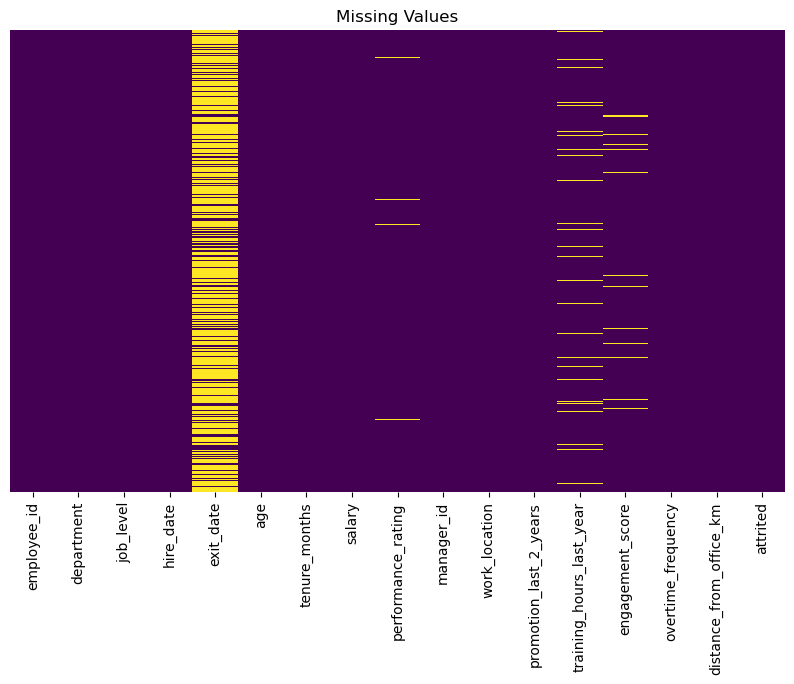

In [34]:
#visualizing missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=False,yticklabels=False,cmap='viridis')
plt.title('Missing Values')
plt.show()

In [36]:
df['performance_rating']=df['performance_rating'].fillna(df['performance_rating'].mean())

In [38]:
df.columns


Index(['employee_id', 'department', 'job_level', 'hire_date', 'exit_date',
       'age', 'tenure_months', 'salary', 'performance_rating', 'manager_id',
       'work_location', 'promotion_last_2_years', 'training_hours_last_year',
       'engagement_score', 'overtime_frequency', 'distance_from_office_km',
       'attrited'],
      dtype='object')

In [40]:
job_level_by_training=df.groupby(by='job_level',as_index=False)['training_hours_last_year'].value_counts(ascending=False)
job_level_by_training

,job_level,training_hours_last_year,count
0,Director,21.0,3
1,Director,24.0,3
2,Director,25.0,3
3,Director,37.0,3
4,Director,11.0,2
...,...,...,...
321,Senior,62.0,1
322,Senior,63.0,1
323,Senior,64.0,1
324,Senior,72.0,1


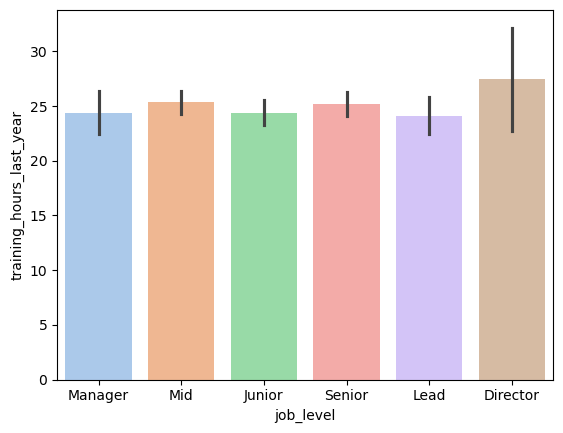

In [48]:
sns.barplot(data=df,x='job_level',y='training_hours_last_year',palette='pastel',hue='job_level')
plt.show()

In [330]:
#filling missing values for training_hours_last_year
df['training_hours_last_year']=df['training_hours_last_year'].fillna(0)


In [334]:
#imputation for :

df['engagement_score']=df['engagement_score'].fillna(df['engagement_score'].median())

In [336]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2521 entries, 0 to 2520
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   employee_id               2521 non-null   object        
 1   department                2521 non-null   object        
 2   job_level                 2521 non-null   object        
 3   hire_date                 2521 non-null   datetime64[ns]
 4   exit_date                 683 non-null    datetime64[ns]
 5   age                       2521 non-null   int64         
 6   tenure_months             2521 non-null   int64         
 7   salary                    2521 non-null   int64         
 8   performance_rating        2521 non-null   float64       
 9   manager_id                2521 non-null   object        
 10  work_location             2521 non-null   object        
 11  promotion_last_2_years    2521 non-null   int64         
 12  training_hours_last_

In [338]:
df.columns

Index(['employee_id', 'department', 'job_level', 'hire_date', 'exit_date',
       'age', 'tenure_months', 'salary', 'performance_rating', 'manager_id',
       'work_location', 'promotion_last_2_years', 'training_hours_last_year',
       'engagement_score', 'overtime_frequency', 'distance_from_office_km',
       'attrited'],
      dtype='object')

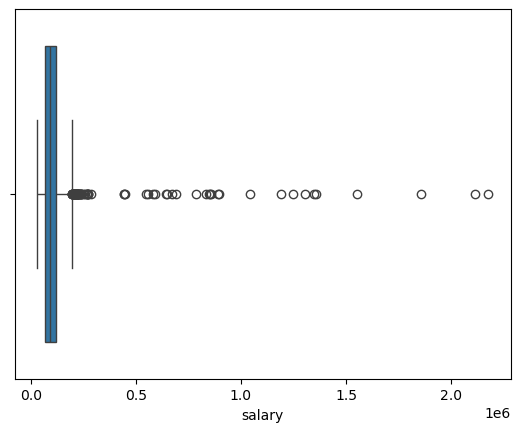

In [340]:
# Detecting Outliars in data

sns.boxplot(x=df['salary'])
plt.show()

In [352]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,hire_date,exit_date,age,tenure_months,salary,performance_rating,promotion_last_2_years,training_hours_last_year,engagement_score,overtime_frequency,distance_from_office_km,attrited
count,2521,683,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00
mean,2021-12-27 06:47:50.289567744,2023-03-24 20:54:27.935578368,33.12,24.74,106427.16,3.52,0.25,23.70,6.49,1.37,14.35,0.27
min,2020-01-01 00:00:00,2020-04-18 00:00:00,22.00,-52.00,31093.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00
25%,2020-12-23 00:00:00,2022-08-13 12:00:00,27.00,12.00,67381.00,3.00,0.00,13.00,5.00,0.00,4.00,0.00
50%,2021-12-26 00:00:00,2023-07-11 00:00:00,32.00,24.00,89422.00,4.00,0.00,23.00,7.00,1.00,10.00,0.00
75%,2023-01-06 00:00:00,2024-01-03 12:00:00,37.00,38.00,118681.00,4.00,1.00,34.00,8.00,2.00,20.00,1.00
max,2023-12-30 00:00:00,2024-05-31 00:00:00,147.00,53.00,2177220.00,5.00,1.00,79.00,10.00,4.00,131.00,1.00
std,NaN,NaN,11.98,15.71,112627.69,1.03,0.44,15.10,2.21,1.20,14.77,0.44


In [368]:
df['salary']=df['salary'].astype(int)

In [370]:
df['salary'].max()

2177220

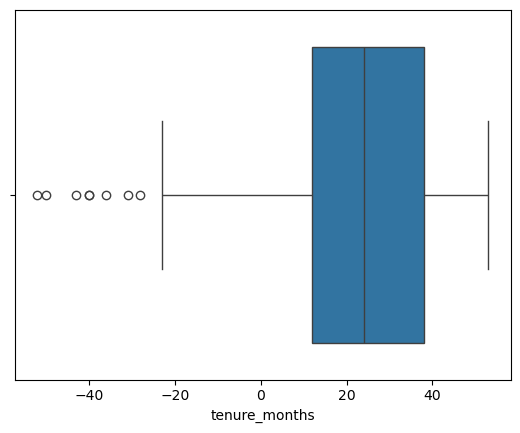

In [354]:
sns.boxplot(x=df['tenure_months'])
plt.show()
        

In [362]:
#handling outliars of tenurity

median_tenure=df.loc[df['tenure_months']>= 0,'tenure_months'].median()
df.loc[df['tenure_months']<0,'tenure_months']=median_tenure



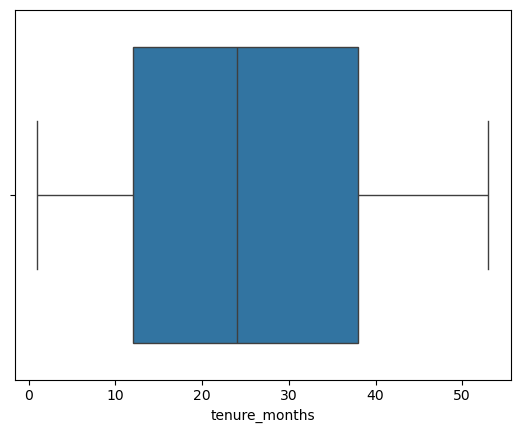

In [364]:
sns.boxplot(x=df['tenure_months'])
plt.show()

In [372]:
df.head()

,employee_id,department,job_level,hire_date,exit_date,age,tenure_months,salary,performance_rating,manager_id,work_location,promotion_last_2_years,training_hours_last_year,engagement_score,overtime_frequency,distance_from_office_km,attrited
0,EMP0001,Sales,Manager,2023-02-04,2024-05-22,44,15,185611,4.00,MGR075,Remote,0,30.00,3.00,2,41,1
1,EMP0002,Sales,Mid,2021-11-17,NaT,25,30,59948,5.00,MGR131,Hybrid,0,0.00,7.00,0,42,0
2,EMP0003,Sales,Junior,2023-11-12,NaT,26,6,38832,4.00,MGR054,Office,1,0.00,10.00,2,5,0
3,EMP0004,Engineering,Mid,2020-03-05,NaT,24,51,90405,3.00,MGR136,Office,1,20.00,8.00,2,22,0
4,EMP0005,Hr,Senior,2022-08-18,NaT,36,21,84459,4.00,MGR005,Remote,1,75.00,6.00,0,1,0


In [376]:
df.describe()

,hire_date,exit_date,age,tenure_months,salary,performance_rating,promotion_last_2_years,training_hours_last_year,engagement_score,overtime_frequency,distance_from_office_km,attrited
count,2521,683,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00,2521.00
mean,2021-12-27 06:47:50.289567744,2023-03-24 20:54:27.935578368,33.12,25.14,106427.16,3.52,0.25,23.70,6.49,1.37,14.35,0.27
min,2020-01-01 00:00:00,2020-04-18 00:00:00,22.00,1.00,31093.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00
25%,2020-12-23 00:00:00,2022-08-13 12:00:00,27.00,12.00,67381.00,3.00,0.00,13.00,5.00,0.00,4.00,0.00
50%,2021-12-26 00:00:00,2023-07-11 00:00:00,32.00,24.00,89422.00,4.00,0.00,23.00,7.00,1.00,10.00,0.00
75%,2023-01-06 00:00:00,2024-01-03 12:00:00,37.00,38.00,118681.00,4.00,1.00,34.00,8.00,2.00,20.00,1.00
max,2023-12-30 00:00:00,2024-05-31 00:00:00,147.00,53.00,2177220.00,5.00,1.00,79.00,10.00,4.00,131.00,1.00
std,NaN,NaN,11.98,14.99,112627.69,1.03,0.44,15.10,2.21,1.20,14.77,0.44


In [378]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2521 entries, 0 to 2520
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   employee_id               2521 non-null   object        
 1   department                2521 non-null   object        
 2   job_level                 2521 non-null   object        
 3   hire_date                 2521 non-null   datetime64[ns]
 4   exit_date                 683 non-null    datetime64[ns]
 5   age                       2521 non-null   int64         
 6   tenure_months             2521 non-null   int64         
 7   salary                    2521 non-null   int64         
 8   performance_rating        2521 non-null   float64       
 9   manager_id                2521 non-null   object        
 10  work_location             2521 non-null   object        
 11  promotion_last_2_years    2521 non-null   int64         
 12  training_hours_last_

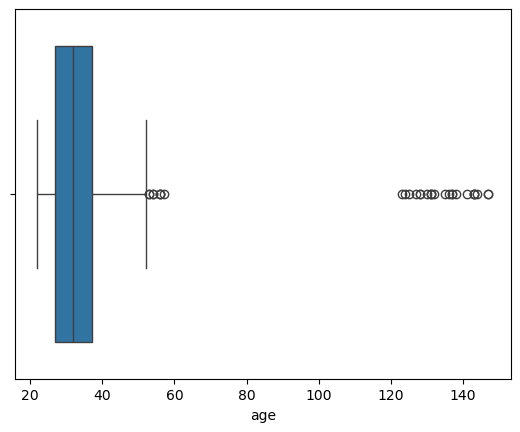

In [380]:
sns.boxplot(x=df['age'])
plt.show()

In [382]:
df['age'].unique()

array([ 44,  25,  26,  24,  36, 125,  27,  34,  28,  37,  30,  42,  35,
        38,  46,  22,  39,  31,  33,  32,  40,  29,  23,  43,  48,  41,
        49,  45,  47, 137,  50,  52, 135, 131, 128,  54,  51,  56, 147,
       143, 127,  53, 130, 138, 124,  57, 136, 132, 144, 141, 123])

In [390]:
bins = [20, 30, 40, 50, 60,150]  # You can adjust upper limit if needed
labels = ['20s', '30s', '40s', '50s', '60+']

#Create age group column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print(df[['age', 'age_group']].head())
         

   age age_group
0   44       40s
1   25       20s
2   26       20s
3   24       20s
4   36       30s


In [392]:
df.duplicated().sum()

21

In [402]:
df=df.drop_duplicates(keep='first')

In [406]:
df.shape

(2500, 18)

In [408]:
df.duplicated().sum()


0

# Data Explratory Analysis

In [412]:
df.describe()

,hire_date,exit_date,age,tenure_months,salary,performance_rating,promotion_last_2_years,training_hours_last_year,engagement_score,overtime_frequency,distance_from_office_km,attrited
count,2500,676,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,2021-12-25 21:01:26.400000256,2023-03-25 22:00:42.603550208,33.14,25.21,106412.64,3.52,0.25,23.69,6.49,1.37,14.37,0.27
min,2020-01-01 00:00:00,2020-04-18 00:00:00,22.00,1.00,31093.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00
25%,2020-12-21 18:00:00,2022-08-14 00:00:00,27.00,12.00,66949.25,3.00,0.00,13.00,5.00,0.00,4.00,0.00
50%,2021-12-21 12:00:00,2023-07-13 00:00:00,32.00,24.00,89304.50,4.00,0.00,23.00,7.00,1.00,10.00,0.00
75%,2023-01-03 00:00:00,2024-01-03 06:00:00,37.00,38.00,118614.00,4.00,1.00,34.00,8.00,2.00,20.00,1.00
max,2023-12-30 00:00:00,2024-05-31 00:00:00,147.00,53.00,2177220.00,5.00,1.00,79.00,10.00,4.00,131.00,1.00
std,NaN,NaN,12.01,15.00,113074.37,1.04,0.44,15.10,2.21,1.20,14.75,0.44


In [414]:
df.columns

Index(['employee_id', 'department', 'job_level', 'hire_date', 'exit_date',
       'age', 'tenure_months', 'salary', 'performance_rating', 'manager_id',
       'work_location', 'promotion_last_2_years', 'training_hours_last_year',
       'engagement_score', 'overtime_frequency', 'distance_from_office_km',
       'attrited', 'age_group'],
      dtype='object')

In [436]:
attrition_rate_by_department = df.groupby(by='department',as_index=False)['attrited'].value_counts().sort_values('attrited',ascending=False)
attrition_rate_by_department

,department,attrited,count
1,Customer Success,1,43
3,Engineering,1,233
5,Finance,1,41
7,Hr,1,58
9,Marketing,1,83
11,Operations,1,46
13,Product,1,8
15,Sales,1,164
0,Customer Success,0,73
2,Engineering,0,690


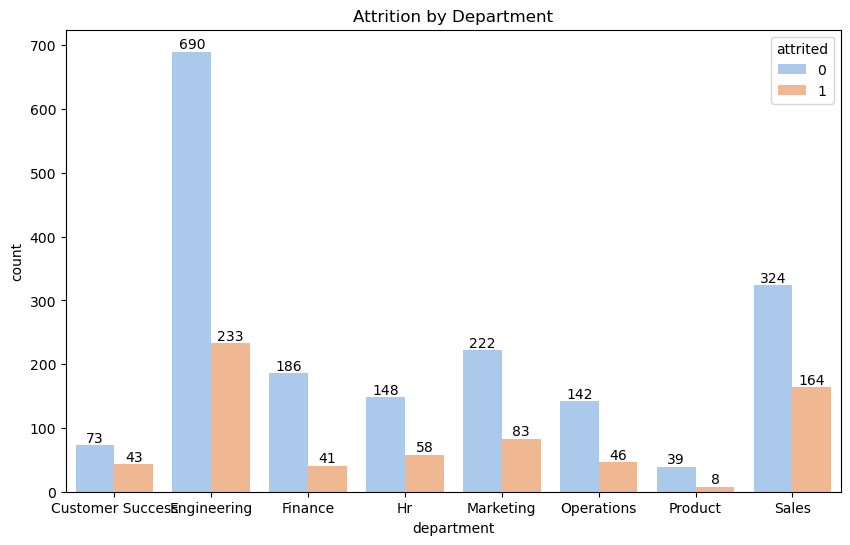

In [480]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=attrition_rate_by_department,x='department',y='count',palette='pastel',hue='attrited')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Attrition by Department')
plt.show()

In [457]:
Attrition_Total = df[df['attrited']==1].shape[0] #shape[0] count how many number of rows
print(f" Attrition Total = {Attrition_Total}")

 Attrition Total = 676


In [467]:
Attrition_Rate = (df['attrited'].value_counts(normalize=True)[1])*100
print(f" Attrition Rate : {Attrition_Rate}%")

 Attrition Rate : 27.04%


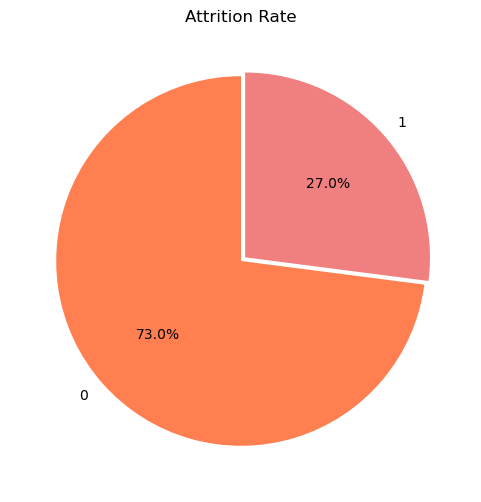

In [477]:
Attrition_count = df['attrited'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(Attrition_count,labels=Attrition_count.index,autopct='%1.1f%%',startangle=90,colors=['coral','lightcoral'],explode=[0,0.03])
plt.title('Attrition Rate')
plt.axis=('equal')
plt.show()

In [482]:
df.columns

Index(['employee_id', 'department', 'job_level', 'hire_date', 'exit_date',
       'age', 'tenure_months', 'salary', 'performance_rating', 'manager_id',
       'work_location', 'promotion_last_2_years', 'training_hours_last_year',
       'engagement_score', 'overtime_frequency', 'distance_from_office_km',
       'attrited', 'age_group'],
      dtype='object')

In [498]:
bins=[12,24,36,48,60,72,84]
labels =['1y','2y','3y','4y','5y','5+']
df.loc[:,'tenure_new']=pd.cut(df['tenure_months'],bins=bins,labels=labels,right=False)


In [500]:
df.columns

Index(['employee_id', 'department', 'job_level', 'hire_date', 'exit_date',
       'age', 'tenure_months', 'salary', 'performance_rating', 'manager_id',
       'work_location', 'promotion_last_2_years', 'training_hours_last_year',
       'engagement_score', 'overtime_frequency', 'distance_from_office_km',
       'attrited', 'age_group', 'tenure', 'tenure_new'],
      dtype='object')

In [508]:
attrition_by_tenure = df.groupby(by='tenure_new',as_index=False)['attrited'].value_counts()
attrition_by_tenure

/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_59314/735180263.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_tenure = df.groupby(by='tenure_new',as_index=False)['attrited'].value_counts()


,tenure_new,attrited,count
0,1y,0,443
1,1y,1,182
2,2y,0,474
3,2y,1,98
4,3y,0,430
5,3y,1,44
6,4y,0,241
7,4y,1,2
8,5y,0,0
9,5y,1,0


In [510]:
df.head()

,employee_id,department,job_level,hire_date,exit_date,age,tenure_months,salary,performance_rating,manager_id,work_location,promotion_last_2_years,training_hours_last_year,engagement_score,overtime_frequency,distance_from_office_km,attrited,age_group,tenure,tenure_new
0,EMP0001,Sales,Manager,2023-02-04,2024-05-22,44,15,185611,4.00,MGR075,Remote,0,30.00,3.00,2,41,1,40s,1y,1y
1,EMP0002,Sales,Mid,2021-11-17,NaT,25,30,59948,5.00,MGR131,Hybrid,0,0.00,7.00,0,42,0,20s,2y,2y
2,EMP0003,Sales,Junior,2023-11-12,NaT,26,6,38832,4.00,MGR054,Office,1,0.00,10.00,2,5,0,20s,NaN,NaN
3,EMP0004,Engineering,Mid,2020-03-05,NaT,24,51,90405,3.00,MGR136,Office,1,20.00,8.00,2,22,0,20s,4y,4y
4,EMP0005,Hr,Senior,2022-08-18,NaT,36,21,84459,4.00,MGR005,Remote,1,75.00,6.00,0,1,0,30s,1y,1y


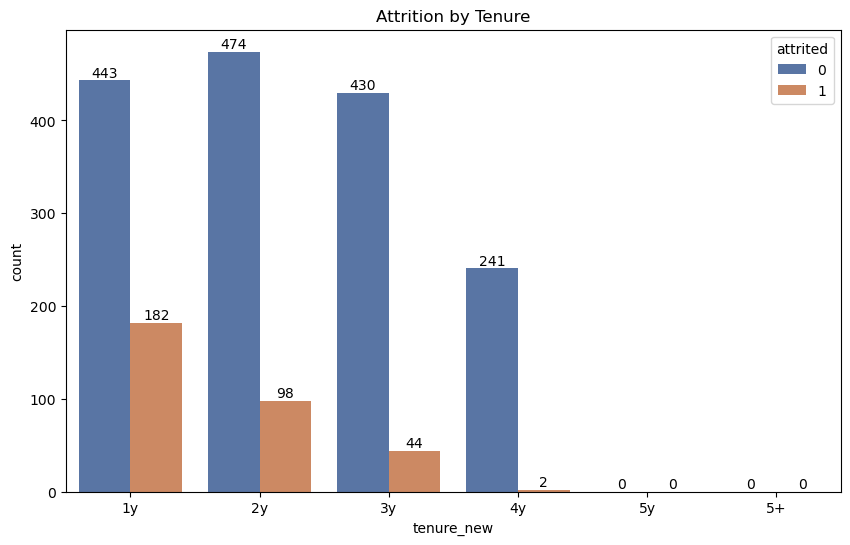

In [512]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=attrition_by_tenure,x='tenure_new',y='count',palette='deep',hue='attrited')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Attrition by Tenure')
plt.show()

In [521]:
#Attriation By Performance

df.columns

Index(['employee_id', 'department', 'job_level', 'hire_date', 'exit_date',
       'age', 'tenure_months', 'salary', 'performance_rating', 'manager_id',
       'work_location', 'promotion_last_2_years', 'training_hours_last_year',
       'engagement_score', 'overtime_frequency', 'distance_from_office_km',
       'attrited', 'age_group', 'tenure', 'tenure_new'],
      dtype='object')

In [525]:
df['performance_rating'].unique()

array([4.        , 5.        , 3.        , 1.        , 2.        ,
       3.52467638])

In [531]:
Attriation_by_Performance = df.groupby(by='performance_rating',as_index=False)['attrited'].value_counts()
Attriation_by_Performance

,performance_rating,attrited,count
0,1.00,1,79
1,1.00,0,57
2,2.00,1,140
3,2.00,0,110
4,3.00,0,452
5,3.00,1,180
6,3.52,0,39
7,3.52,1,9
8,4.00,0,856
9,4.00,1,203


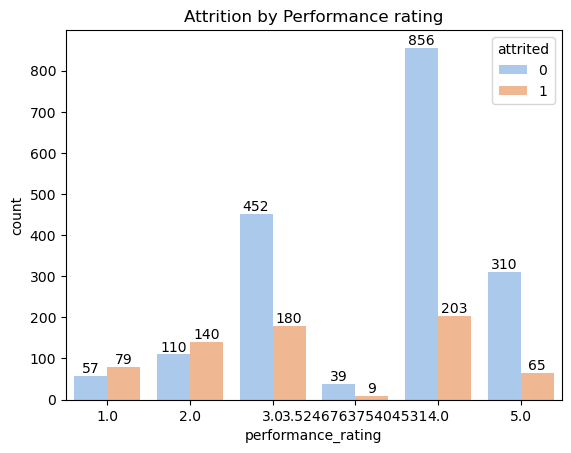

In [557]:
#plt.figure(figsize=(6,6))
ax=sns.barplot(Attriation_by_Performance,x='performance_rating',y='count',hue='attrited',palette='pastel')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Attrition by Performance rating')
plt.show()

## Observation: 
### Total Attriation Rate is `27%`
### Engineering Department has highest Attiration
### 12 months of Tenurity has highest Attriation Rate
### Low performace has high Attrition Rate

# Feature Engineering

In [570]:
#salary_bins = [0,30000,50000,75000,100000,df['salary'].max()]
#salary_labels =['<30k','30-50k','50-75k','75-100k','100k+']
#df['salary_band']=pd.cut(df['salary'],bins=salary_bins,labels=salary_labels,right=False)

In [578]:
df['salary_band']=pd.qcut(df['salary'],q=4,labels=['low','medium','high','very high'])


In [580]:
df['salary_band']

0       very high
1             low
2             low
3            high
4          medium
          ...    
2516       medium
2517          low
2518    very high
2519    very high
2520         high
Name: salary_band, Length: 2500, dtype: category
Categories (4, object): ['low' < 'medium' < 'high' < 'very high']

In [582]:
df.columns

Index(['employee_id', 'department', 'job_level', 'hire_date', 'exit_date',
       'age', 'tenure_months', 'salary', 'performance_rating', 'manager_id',
       'work_location', 'promotion_last_2_years', 'training_hours_last_year',
       'engagement_score', 'overtime_frequency', 'distance_from_office_km',
       'attrited', 'age_group', 'tenure', 'tenure_new', 'salary_band'],
      dtype='object')

In [588]:
df['engagement_score'].unique().sum()

55.0

In [594]:
df['engagement_score'].max()

10.0

In [599]:
corr_matrix =df.corr(numeric_only=True)
corr_matrix

,age,tenure_months,salary,performance_rating,promotion_last_2_years,training_hours_last_year,engagement_score,overtime_frequency,distance_from_office_km,attrited
age,1.00,-0.02,0.17,-0.02,-0.00,0.01,-0.00,-0.02,-0.00,0.01
tenure_months,-0.02,1.00,0.04,0.12,0.02,0.01,0.10,-0.06,-0.00,-0.45
salary,0.17,0.04,1.00,0.02,-0.01,0.00,-0.01,0.01,0.00,-0.01
performance_rating,-0.02,0.12,0.02,1.00,-0.01,0.01,0.00,-0.01,-0.02,-0.27
promotion_last_2_years,-0.00,0.02,-0.01,-0.01,1.00,-0.00,-0.02,0.02,-0.01,-0.05
training_hours_last_year,0.01,0.01,0.00,0.01,-0.00,1.00,-0.01,-0.01,0.04,-0.01
engagement_score,-0.00,0.10,-0.01,0.00,-0.02,-0.01,1.00,-0.01,0.00,-0.24
overtime_frequency,-0.02,-0.06,0.01,-0.01,0.02,-0.01,-0.01,1.00,0.01,0.10
distance_from_office_km,-0.00,-0.00,0.00,-0.02,-0.01,0.04,0.00,0.01,1.00,0.01
attrited,0.01,-0.45,-0.01,-0.27,-0.05,-0.01,-0.24,0.10,0.01,1.00


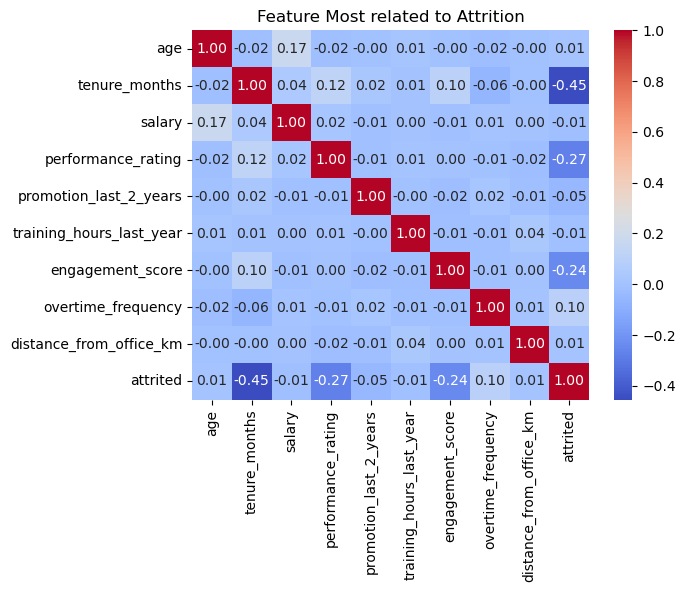

In [609]:
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Feature Most related to Attrition')
plt.show()
            

# Predictive Model

In [611]:
#Prepare for Modelling
print('Prepration for Data Modelling')

Prepration for Data Modelling


In [613]:
df.columns


Index(['employee_id', 'department', 'job_level', 'hire_date', 'exit_date',
       'age', 'tenure_months', 'salary', 'performance_rating', 'manager_id',
       'work_location', 'promotion_last_2_years', 'training_hours_last_year',
       'engagement_score', 'overtime_frequency', 'distance_from_office_km',
       'attrited', 'age_group', 'tenure', 'tenure_new', 'salary_band'],
      dtype='object')

In [615]:
df.describe(include=int)

,age,tenure_months,salary,promotion_last_2_years,overtime_frequency,distance_from_office_km,attrited
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,33.14,25.21,106412.64,0.25,1.37,14.37,0.27
std,12.01,15.00,113074.37,0.44,1.20,14.75,0.44
min,22.00,1.00,31093.00,0.00,0.00,1.00,0.00
25%,27.00,12.00,66949.25,0.00,0.00,4.00,0.00
50%,32.00,24.00,89304.50,0.00,1.00,10.00,0.00
75%,37.00,38.00,118614.00,1.00,2.00,20.00,1.00
max,147.00,53.00,2177220.00,1.00,4.00,131.00,1.00


In [627]:
#Select feature for modeling

numeric_features=['age','tenure_months','salary','promotion_last_2_years','overtime_frequency','distance_from_office_km']
categorical_features=['department','job_level','work_location','promotion_last_2_years','tenure_new','salary_band']

In [639]:
features_df=df.copy()

In [641]:
from sklearn.impute import SimpleImputer

In [645]:
# Numeric features - fill with median
numeric_imputer = SimpleImputer(strategy='median')
features_df[numeric_features] = numeric_imputer.fit_transform(features_df[numeric_features])

# Categorical features - fill with mode
for col in categorical_features:
    features_df[col] = features_df[col].fillna(features_df[col].mode()[0])


In [647]:
#create Dummy variables for categorical features
features_encoded=pd.get_dummies(features_df[categorical_features],drop_first=True)

In [653]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [657]:
# Combine numeric and encoded categorical features
X = pd.concat([features_df[numeric_features], features_encoded], axis=1)
y = features_df['attrited']

print(f"Final feature matrix shape: {X.shape}")
print(f"Target variable distribution:")
print(y.value_counts(normalize=True))

Final feature matrix shape: (2500, 29)
Target variable distribution:
attrited
0   0.73
1   0.27
Name: proportion, dtype: float64


In [659]:
# Step 5: Split Data
print("\n=== STEP 5: TRAIN-TEST SPLIT ===")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


=== STEP 5: TRAIN-TEST SPLIT ===
Training set: (2000, 29)
Test set: (500, 29)


In [661]:
# Step 6: Scale Features
print("\n=== STEP 6: FEATURE SCALING ===")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


=== STEP 6: FEATURE SCALING ===


In [663]:

# Step 7: Build Logistic Regression Model
print("\n=== STEP 7: LOGISTIC REGRESSION MODEL ===")

# Initialize and train model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Model training completed!")



=== STEP 7: LOGISTIC REGRESSION MODEL ===
Model training completed!


In [665]:
# Step 8: Model Evaluation
print("\n=== STEP 8: MODEL EVALUATION ===")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ROC-AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.3f}")




=== STEP 8: MODEL EVALUATION ===
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       365
           1       0.64      0.50      0.56       135

    accuracy                           0.79       500
   macro avg       0.73      0.70      0.71       500
weighted avg       0.78      0.79      0.78       500


Confusion Matrix:
[[326  39]
 [ 67  68]]

ROC-AUC Score: 0.794



=== STEP 9: FEATURE IMPORTANCE ===
Top 10 Most Important Features:
                  feature  coefficient  abs_coefficient
1           tenure_months        -2.16             2.16
22          tenure_new_3y         0.83             0.83
14       job_level_Junior        -0.76             0.76
28  salary_band_very high        -0.56             0.56
21          tenure_new_2y         0.53             0.53
17          job_level_Mid        -0.52             0.52
18       job_level_Senior        -0.43             0.43
23          tenure_new_4y         0.36             0.36
27       salary_band_high        -0.33             0.33
8      department_Finance        -0.28             0.28

=== STEP 10: BUSINESS INSIGHTS ===

High-risk employees identified: 46
Sample high-risk employee characteristics:
       department job_level  tenure_months  engagement_score  \
1539  Engineering    Junior           4.00              7.00   
1849    Marketing   Manager           3.00              6.00   
708      

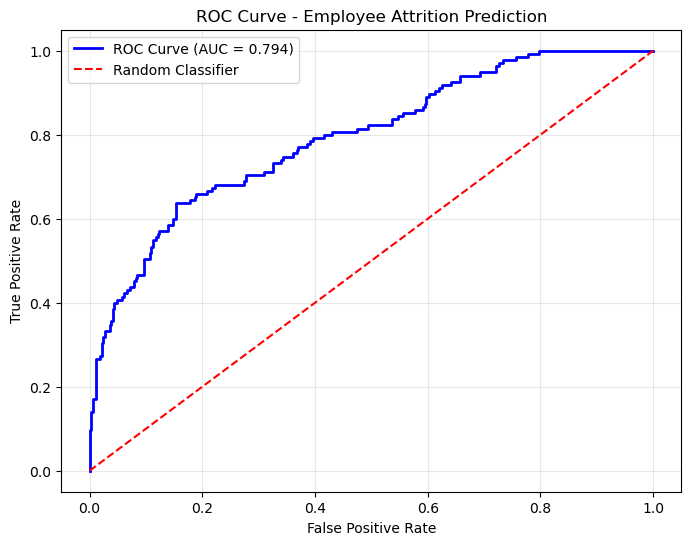


=== LOGISTIC REGRESSION ANALYSIS COMPLETE ===
Your model is ready for presentation!


In [667]:
# Step 9: Feature Importance
print("\n=== STEP 9: FEATURE IMPORTANCE ===")

# Get feature importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0],
    'abs_coefficient': abs(log_reg.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Step 10: Business Insights
print("\n=== STEP 10: BUSINESS INSIGHTS ===")

# High-risk employees (probability > 0.7)
high_risk_threshold = 0.7
high_risk_indices = np.where(y_pred_proba > high_risk_threshold)[0]

if len(high_risk_indices) > 0:
    print(f"\nHigh-risk employees identified: {len(high_risk_indices)}")
    print("Sample high-risk employee characteristics:")
    
    # Get original indices in test set
    test_indices = X_test.index[high_risk_indices[:5]]  # First 5 high-risk employees
    
    risk_profiles = features_df.loc[test_indices, ['department', 'job_level', 'tenure_months', 
                                                  'engagement_score', 'performance_rating', 'salary']]
    print(risk_profiles)

# Key findings for business
print("\n=== KEY BUSINESS INSIGHTS ===")
print("1. Model Performance:")
print(f"   - ROC-AUC Score: {auc_score:.3f} ({'Good' if auc_score > 0.7 else 'Needs Improvement'})")
print(f"   - Identified {len(high_risk_indices)} high-risk employees")

print("\n2. Top Risk Factors (based on feature importance):")
top_factors = feature_importance.head(5)['feature'].tolist()
for i, factor in enumerate(top_factors, 1):
    print(f"   {i}. {factor}")

print("\n3. Recommendations:")
print("   - Focus retention efforts on high-risk employees")
print("   - Address top risk factors through targeted interventions")
print("   - Monitor employees with similar profiles to high-risk group")
print("   - Implement early warning system using this model")

# Optional: Plot ROC Curve
print("\n=== OPTIONAL: ROC CURVE VISUALIZATION ===")
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Employee Attrition Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== LOGISTIC REGRESSION ANALYSIS COMPLETE ===")
print("Your model is ready for presentation!")